<a href="https://colab.research.google.com/github/Mr-Faizan-Asim/DeepCore-AI/blob/master/Hackney_Accident_Work.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Step 0: Setup
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

from IPython.display import display, HTML
display(HTML("<style>.container { width:100% !important; }</style>"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from scipy.stats import zscore


In [2]:
# Step 1: Upload and load the Excel file (run this in Colab)
from google.colab import files

uploaded = files.upload()  # upload a.xlsx here manually

# If your file is named exactly 'a.xlsx':
acc = pd.read_excel('Hackney.xlsx')

print("Samples of the data:")
display(acc.head())

print("\nData types recognised by Python:")
display(acc.dtypes)

print("\nThe total number of rows and columns of the data:")
print(acc.shape)

print("\nFull info:")
acc.info()


Saving Hackney.xlsx to Hackney.xlsx
Samples of the data:


,Accident_Index,Location_Easting_OSGR,Location_Northing_OSGR,Longitude,Latitude,Police_Force,Accident_Severity,Number_of_Vehicles,Number_of_Casualties,Date,...,Pedestrian_Crossing-Human_Control,Pedestrian_Crossing-Physical_Facilities,Light_Conditions,Weather_Conditions,Road_Surface_Conditions,Special_Conditions_at_Site,Carriageway_Hazards,Urban_or_Rural_Area,Did_Police_Officer_Attend_Scene_of_Accident,LSOA_of_Accident_Location
0,200501CP00187,532960,181880,-0.085002,51.520143,1,2,2,1,2005-08-25,...,0,0,4,1,1,0,0,1,1,E01000004
1,200501EK40106,531540,186860,-0.103597,51.565229,1,3,2,1,2005-02-19,...,0,0,1,1,1,0,0,1,2,E01002002
2,200501EO00029,532880,182520,-0.085913,51.525914,1,3,2,2,2005-01-10,...,0,0,1,2,2,0,0,1,1,E01002704
3,200501EO00043,533280,184790,-0.079292,51.546219,1,3,2,1,2005-01-12,...,0,0,1,1,1,0,0,1,1,E01001756
4,200501EO00144,533240,182630,-0.080685,51.526817,1,3,2,1,2005-01-21,...,0,5,4,2,2,0,0,1,1,E01001771



Data types recognised by Python:


,0
Accident_Index,object
Location_Easting_OSGR,int64
Location_Northing_OSGR,int64
Longitude,float64
Latitude,float64
Police_Force,int64
Accident_Severity,int64
Number_of_Vehicles,int64
Number_of_Casualties,int64
Date,datetime64[ns]



The total number of rows and columns of the data:
(4857, 32)

Full info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4857 entries, 0 to 4856
Data columns (total 32 columns):
 #   Column                                       Non-Null Count  Dtype         
---  ------                                       --------------  -----         
 0   Accident_Index                               4857 non-null   object        
 1   Location_Easting_OSGR                        4857 non-null   int64         
 2   Location_Northing_OSGR                       4857 non-null   int64         
 3   Longitude                                    4857 non-null   float64       
 4   Latitude                                     4857 non-null   float64       
 5   Police_Force                                 4857 non-null   int64         
 6   Accident_Severity                            4857 non-null   int64         
 7   Number_of_Vehicles                           4857 non-null   int64         
 8   Numb

In [3]:
# Step 1b: Fix obvious data type issues

# DIAGNOSTIC: Print original Time column content before any processing
print("\n--- Original 'Time' column content before processing ---")
print("Original 'Time' column dtype:", acc['Time'].dtype)
print("Original 'Time' column non-null count:", acc['Time'].count())
print("Unique values and counts for original 'Time' column (top 20):")
display(acc['Time'].value_counts(dropna=False).head(20))
print("Sample original 'Time' column values:")
display(acc['Time'].head())
print("-----------------------------------------------------------")

# 1) Date → datetime
acc['Date'] = pd.to_datetime(acc['Date'], dayfirst=True, errors='coerce')

# 2) Time → datetime.time (or you can keep it as string)
# The previous attempts to convert 'Time' to datetime using pd.to_datetime failed for all entries,
# indicating highly inconsistent or non-standard formats.
# Let's try a more robust approach by attempting to parse common time string patterns.

# Initialize a new column for parsed datetime objects
parsed_datetime_series = pd.Series(pd.NaT, index=acc.index, dtype='datetime64[ns]')

# Convert the 'Time' column to string type to ensure string methods work, and strip whitespace
time_str_series = acc['Time'].astype(str).str.strip()

# Attempt to parse 'HH:MM' (e.g., '14:30', '1:05')
mask_hh_mm = time_str_series.str.match(r'^\d{1,2}:\d{2}$', na=False)
parsed_datetime_series[mask_hh_mm] = pd.to_datetime(time_str_series[mask_hh_mm], format='%H:%M', errors='coerce')

# For remaining NaT values, attempt to parse 'HHMM' or 'HMM' (e.g., '1430', '900')
remaining_mask_hhmm_or_hmm = parsed_datetime_series.isna()
mask_digits_only = time_str_series[remaining_mask_hhmm_or_hmm].str.match(r'^\d{3,4}$', na=False)
# Pad with leading zeros to ensure 4 digits for %H%M format, e.g., '900' becomes '0900'
to_parse_hhmm = time_str_series[remaining_mask_hhmm_or_hmm][mask_digits_only].apply(lambda x: x.zfill(4))
parsed_datetime_series.loc[remaining_mask_hhmm_or_hmm & mask_digits_only] = pd.to_datetime(to_parse_hhmm, format='%H%M', errors='coerce')

# For remaining NaT values, attempt to parse 'HH' (e.g., '14', '9') by appending ':00'
remaining_mask_hh = parsed_datetime_series.isna()
mask_hh = time_str_series[remaining_mask_hh].str.match(r'^\d{1,2}$', na=False)
# Pad single digit hours and append ':00', e.g., '9' becomes '09:00'
to_parse_hh = time_str_series[remaining_mask_hh][mask_hh].apply(lambda x: x.zfill(2) + ':00')
parsed_datetime_series.loc[remaining_mask_hh & mask_hh] = pd.to_datetime(to_parse_hh, format='%H:%M', errors='coerce')

# Assign the time component to acc['Time']
acc['Time'] = parsed_datetime_series.dt.time

# Also create an Hour variable (useful later for modelling)
acc['Hour'] = parsed_datetime_series.dt.hour

# 3) Treat ID-like / code-like columns as categorical
categorical_cols = [
    'Accident_Index',
    'Police_Force',
    'Local_Authority_District',
    'Local_Authority_Highway',
    '1st_Road_Class',
    '2nd_Road_Class',
    'Pedestrian_Crossing-Human_Control',
    'Pedestrian_Crossing-Physical_Facilities',
    'Light_Conditions',
    'Weather_Conditions',
    'Road_Surface_Conditions',
    'Special_Conditions_at_Site',
    'Carriageway_Hazards',
    'Urban_or_Rural_Area',
    'Did_Police_Officer_Attend_Scene_of_Accident',
    'LSOA_of_Accident_Location',
    'Day_of_Week',  # numeric but categorical in meaning
]

for col in categorical_cols:
    if col in acc.columns:
        acc[col] = acc[col].astype('category')

print("\nData types after corrections:")
acc.info()

print("\nUnique values and counts for 'Time' column after parsing attempts:")
# Display unique values from the original (string) 'Time' column to understand its format
display(acc['Time'].astype(str).value_counts(dropna=False).head(20))

print("\nSample original 'Time' column values:")
display(acc['Time'].head())


--- Original 'Time' column content before processing ---
Original 'Time' column dtype: object
Original 'Time' column non-null count: 4857
Unique values and counts for original 'Time' column (top 20):


,count
Time,
18:30:00,43
17:30:00,42
18:00:00,42
19:00:00,40
16:00:00,40
15:00:00,38
15:30:00,38
20:00:00,38
08:30:00,33


Sample original 'Time' column values:


,Time
0,00:41:00
1,06:47:00
2,14:30:00
3,13:13:00
4,01:37:00


-----------------------------------------------------------

Data types after corrections:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4857 entries, 0 to 4856
Data columns (total 33 columns):
 #   Column                                       Non-Null Count  Dtype         
---  ------                                       --------------  -----         
 0   Accident_Index                               4857 non-null   category      
 1   Location_Easting_OSGR                        4857 non-null   int64         
 2   Location_Northing_OSGR                       4857 non-null   int64         
 3   Longitude                                    4857 non-null   float64       
 4   Latitude                                     4857 non-null   float64       
 5   Police_Force                                 4857 non-null   category      
 6   Accident_Severity                            4857 non-null   int64         
 7   Number_of_Vehicles                           4857 non-null   int64  

,count
Time,
NaT,4857



Sample original 'Time' column values:


,Time
0,NaT
1,NaT
2,NaT
3,NaT
4,NaT


In [4]:
# Step 2: Initial exploration

numeric_acc = acc.select_dtypes(include=['int64', 'float64'])
categorical_acc = acc.select_dtypes(include=['object', 'category'])

print("Number of numeric variables:", len(numeric_acc.columns))
print("Number of categorical variables:", len(categorical_acc.columns))

print("\nNumeric variables:")
display(numeric_acc.columns)

print("\nCategorical variables:")
display(categorical_acc.columns)


Number of numeric variables: 14
Number of categorical variables: 17

Numeric variables:


Index(['Location_Easting_OSGR', 'Location_Northing_OSGR', 'Longitude',
       'Latitude', 'Accident_Severity', 'Number_of_Vehicles',
       'Number_of_Casualties', '1st_Road_Number', 'Road_Type', 'Speed_limit',
       'Junction_Detail', 'Junction_Control', '2nd_Road_Number', 'Hour'],
      dtype='object')


Categorical variables:


Index(['Accident_Index', 'Police_Force', 'Day_of_Week',
       'Local_Authority_District', 'Local_Authority_Highway', '1st_Road_Class',
       '2nd_Road_Class', 'Pedestrian_Crossing-Human_Control',
       'Pedestrian_Crossing-Physical_Facilities', 'Light_Conditions',
       'Weather_Conditions', 'Road_Surface_Conditions',
       'Special_Conditions_at_Site', 'Carriageway_Hazards',
       'Urban_or_Rural_Area', 'Did_Police_Officer_Attend_Scene_of_Accident',
       'LSOA_of_Accident_Location'],
      dtype='object')

In [5]:
# Basic stats for numeric variables (range, mean, std, skew, kurtosis, mode)
basic_stats = numeric_acc.describe().T  # count, mean, std, min, 25%, 50%, 75%, max

# Add skewness and kurtosis
basic_stats['skew'] = numeric_acc.skew()
basic_stats['kurtosis'] = numeric_acc.kurtosis()

# Add mode (first mode if multiple)
modes = numeric_acc.mode().iloc[0]
basic_stats['mode'] = modes

print("Basic statistics for numeric variables:")
display(basic_stats)

# Basic stats for categorical variables
print("\nBasic statistics for categorical variables (top, freq, unique):")
display(categorical_acc.describe().T)


Basic statistics for numeric variables:


,count,mean,std,min,25%,50%,75%,max,skew,kurtosis,mode
Location_Easting_OSGR,4857.0,534002.268890,1160.535793,531500.000000,533340.000000,533670.000000,534860.000000,537590.000000,0.447452,0.124879,533470.000000
Location_Northing_OSGR,4857.0,185186.429895,1586.261464,181840.000000,184080.000000,185150.000000,186540.000000,188180.000000,-0.086085,-0.879641,185190.000000
Longitude,4857.0,-0.068732,0.016695,-0.104193,-0.078620,-0.072824,-0.056299,-0.016897,0.472139,0.086480,-0.077209
Latitude,4857.0,51.549609,0.014278,51.519793,51.539456,51.549031,51.561776,51.576455,-0.054068,-0.889155,51.530627
Accident_Severity,4857.0,2.852996,0.370070,1.000000,3.000000,3.000000,3.000000,3.000000,-2.330312,4.477906,3.000000
Number_of_Vehicles,4857.0,1.748816,0.612130,1.000000,1.000000,2.000000,2.000000,8.000000,1.180319,7.451449,2.000000
Number_of_Casualties,4857.0,1.160799,0.527149,1.000000,1.000000,1.000000,1.000000,10.000000,5.715278,55.581084,1.000000
1st_Road_Number,4857.0,254.409512,806.081300,0.000000,0.000000,102.000000,107.000000,5201.000000,5.317721,29.280787,0.000000
Road_Type,4857.0,5.634754,1.145154,1.000000,6.000000,6.000000,6.000000,9.000000,-2.498370,5.975121,6.000000
Speed_limit,4857.0,30.331480,2.581709,20.000000,30.000000,30.000000,30.000000,70.000000,8.651637,86.250161,30.000000



Basic statistics for categorical variables (top, freq, unique):


,count,unique,top,freq
Accident_Index,4857,4857,201001YR90686,1
Police_Force,4857,1,1,4857
Day_of_Week,4857,7,6,795
Local_Authority_District,4857,1,4,4857
Local_Authority_Highway,4857,1,E09000012,4857
1st_Road_Class,4857,4,3,2958
2nd_Road_Class,4857,5,6,1650
Pedestrian_Crossing-Human_Control,4857,3,0,4837
Pedestrian_Crossing-Physical_Facilities,4857,6,0,3385
Light_Conditions,4857,5,1,3417


<Axes: xlabel='Location_Easting_OSGR', ylabel='Count'>

Text(0.5, 1.0, 'Location_Easting_OSGR')

<Axes: xlabel='Location_Northing_OSGR', ylabel='Count'>

Text(0.5, 1.0, 'Location_Northing_OSGR')

<Axes: xlabel='Longitude', ylabel='Count'>

...

Text(0.5, 1.0, 'Junction_Control')

<Axes: xlabel='2nd_Road_Number', ylabel='Count'>

Text(0.5, 1.0, '2nd_Road_Number')

<Axes: xlabel='Hour', ylabel='Count'>

Text(0.5, 1.0, 'Hour')

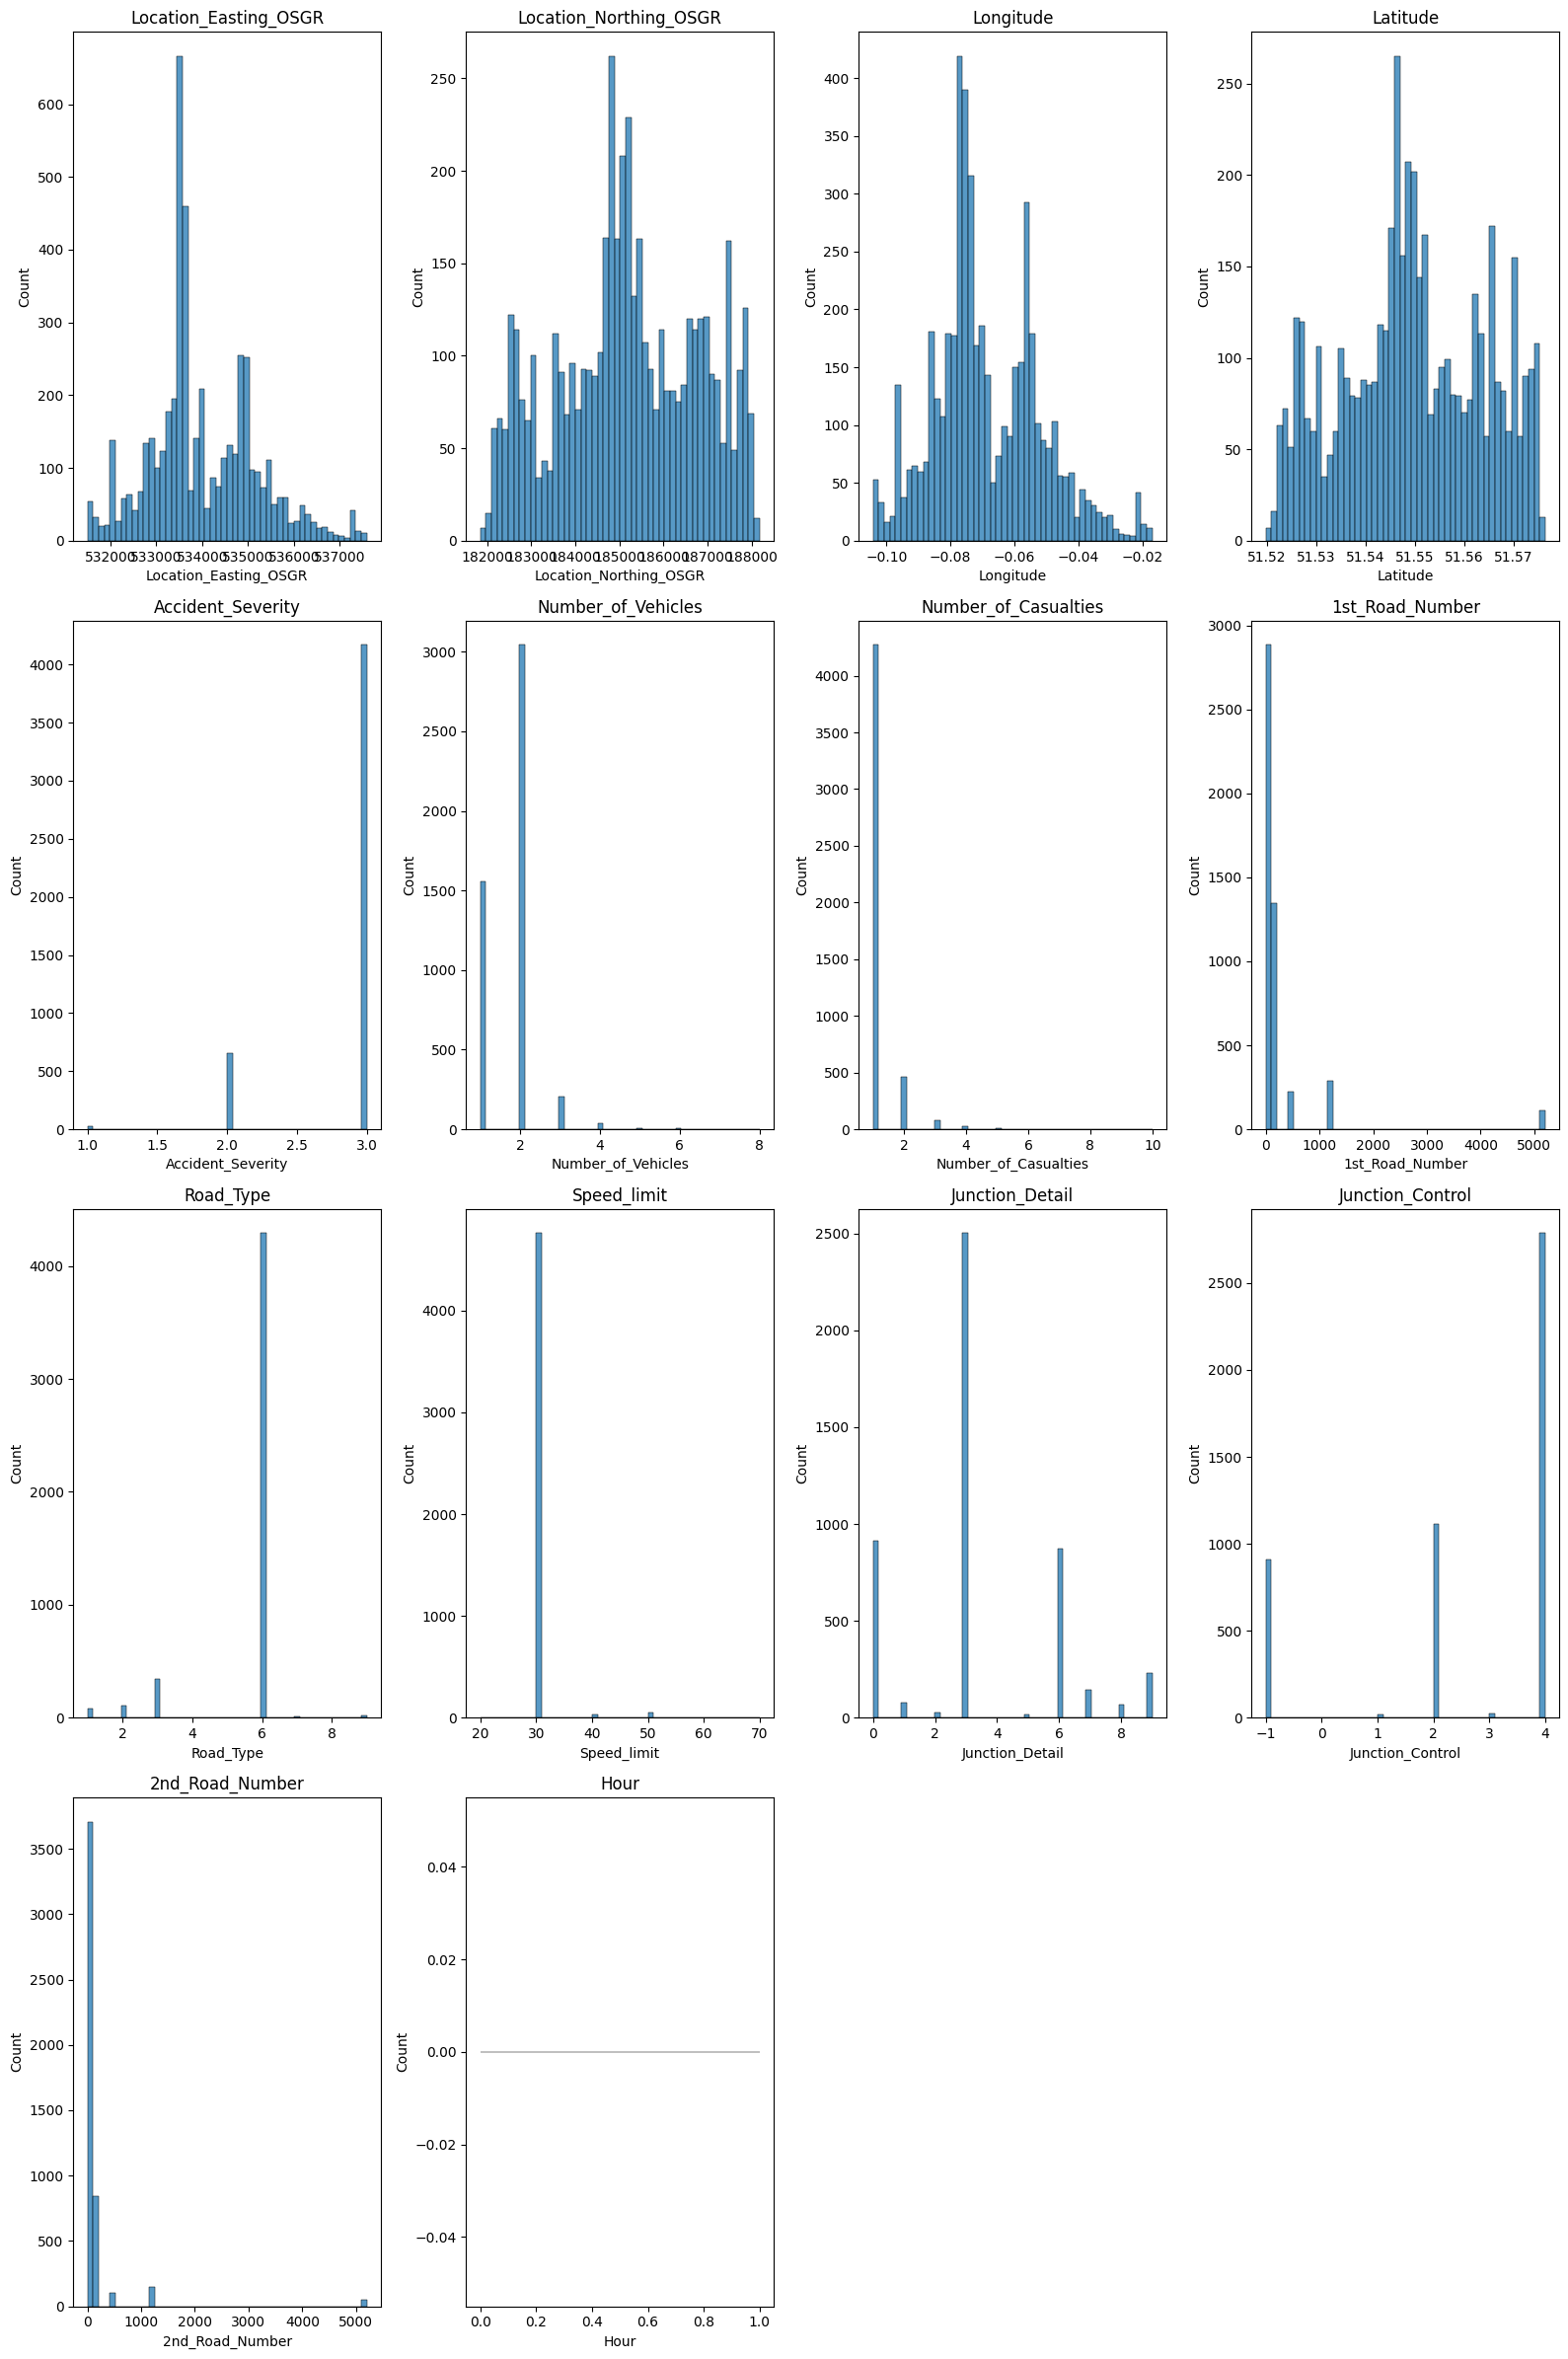

<Axes: xlabel='Location_Easting_OSGR'>

Text(0.5, 1.0, 'Location_Easting_OSGR')

<Axes: xlabel='Location_Northing_OSGR'>

Text(0.5, 1.0, 'Location_Northing_OSGR')

<Axes: xlabel='Longitude'>

...

<Axes: xlabel='2nd_Road_Number'>

Text(0.5, 1.0, '2nd_Road_Number')

Text(0.5, 0.5, 'Constant / empty')

Text(0.5, 1.0, 'Hour')

[]

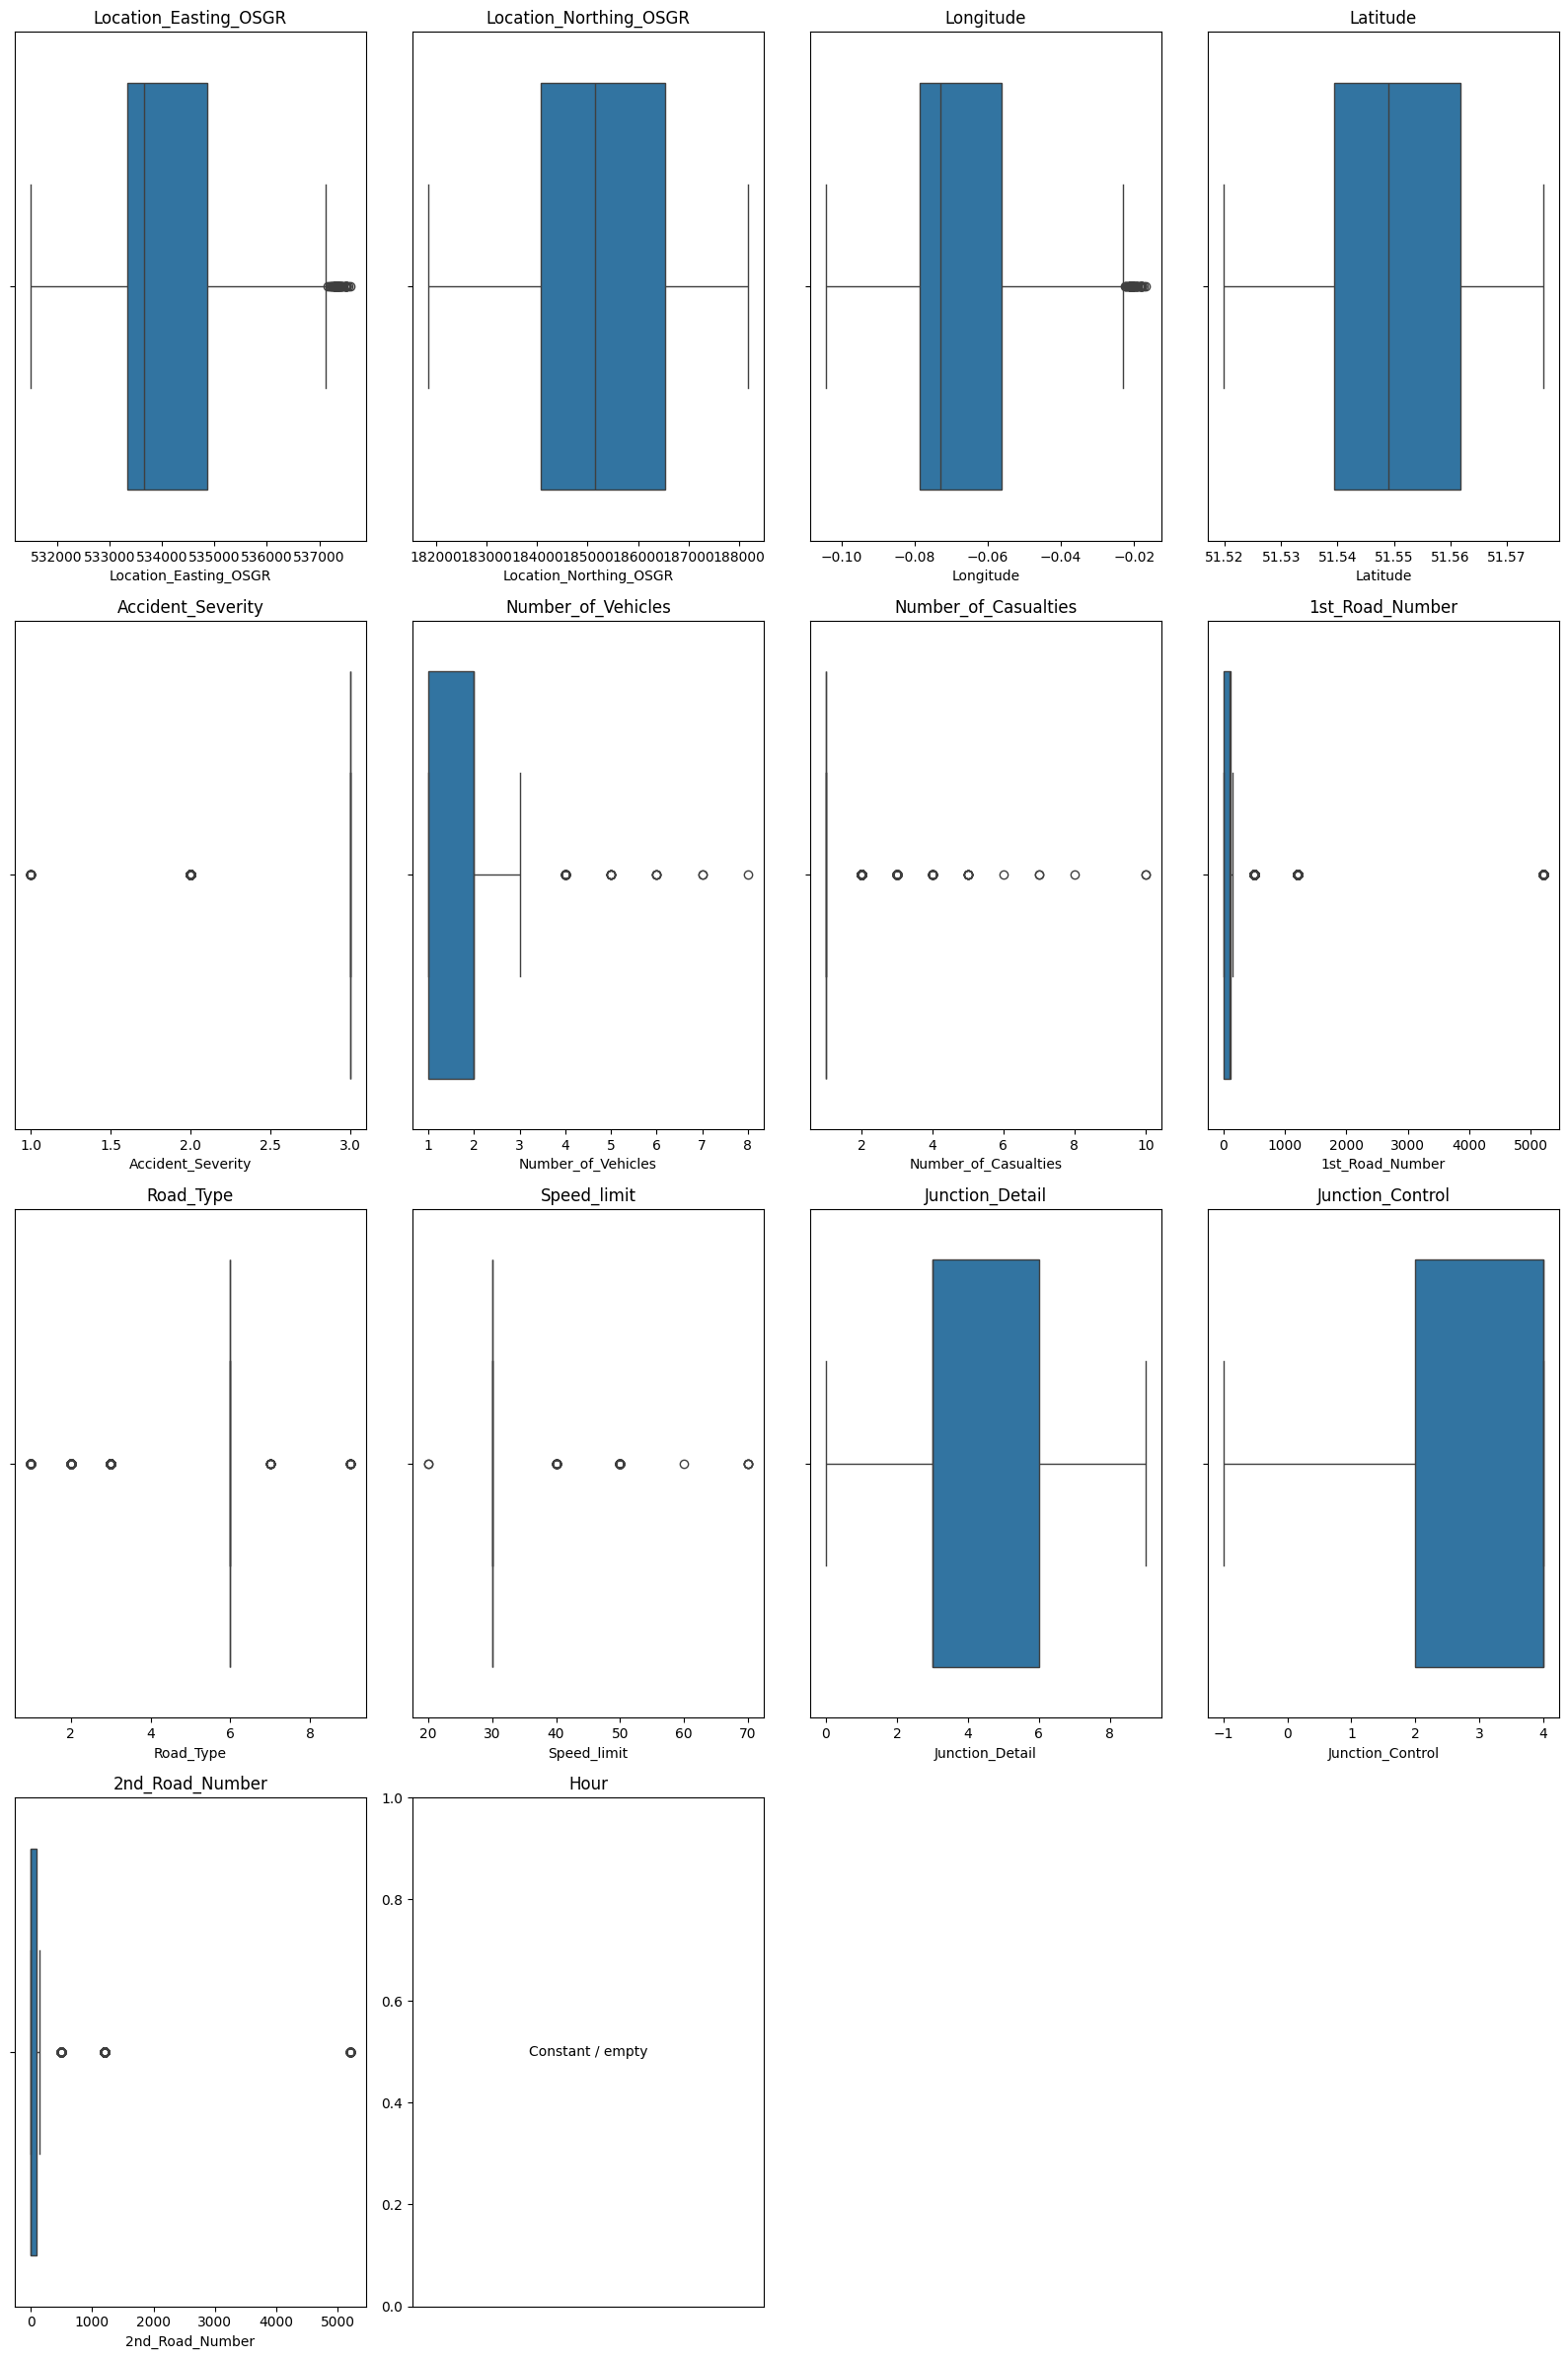

In [6]:
# Histograms for numeric variables
fig = plt.figure(figsize=(16, 24))
for i, column in enumerate(numeric_acc.columns):
    ax = fig.add_subplot(int(np.ceil(len(numeric_acc.columns)/4)), 4, i+1)
    sns.histplot(data=numeric_acc, x=column, bins=50)
    ax.set_title(column)
plt.tight_layout()
plt.show()

# Boxplots for numeric variables (robust version)
fig = plt.figure(figsize=(16, 24))

n_cols = 4
n_rows = int(np.ceil(len(numeric_acc.columns) / n_cols))

for i, column in enumerate(numeric_acc.columns):
    ax = fig.add_subplot(n_rows, n_cols, i+1)

    # Take the series, drop NaNs
    series = numeric_acc[column].dropna()

    # Skip if constant or empty (boxplot is pointless and can cause issues)
    if series.nunique() <= 1:
        ax.text(0.5, 0.5, 'Constant / empty', ha='center', va='center')
        ax.set_title(column)
        ax.set_xticks([])
        continue

    sns.boxplot(x=series, ax=ax)   # 1D data only
    ax.set_title(column)

plt.tight_layout()
plt.show()


Missing values per variable (count):


,0
Time,4857
Hour,4857
LSOA_of_Accident_Location,3
Accident_Index,0
Location_Easting_OSGR,0
Police_Force,0
Accident_Severity,0
Longitude,0
Location_Northing_OSGR,0
Number_of_Casualties,0



Missing values per variable (percentage):


,0
Time,1.000000
Hour,1.000000
LSOA_of_Accident_Location,0.000618
Accident_Index,0.000000
Location_Easting_OSGR,0.000000
Police_Force,0.000000
Accident_Severity,0.000000
Longitude,0.000000
Location_Northing_OSGR,0.000000
Number_of_Casualties,0.000000


<Figure size 1000x600 with 0 Axes>

<Axes: >

Text(0.5, 1.0, 'Missing Values Heatmap')

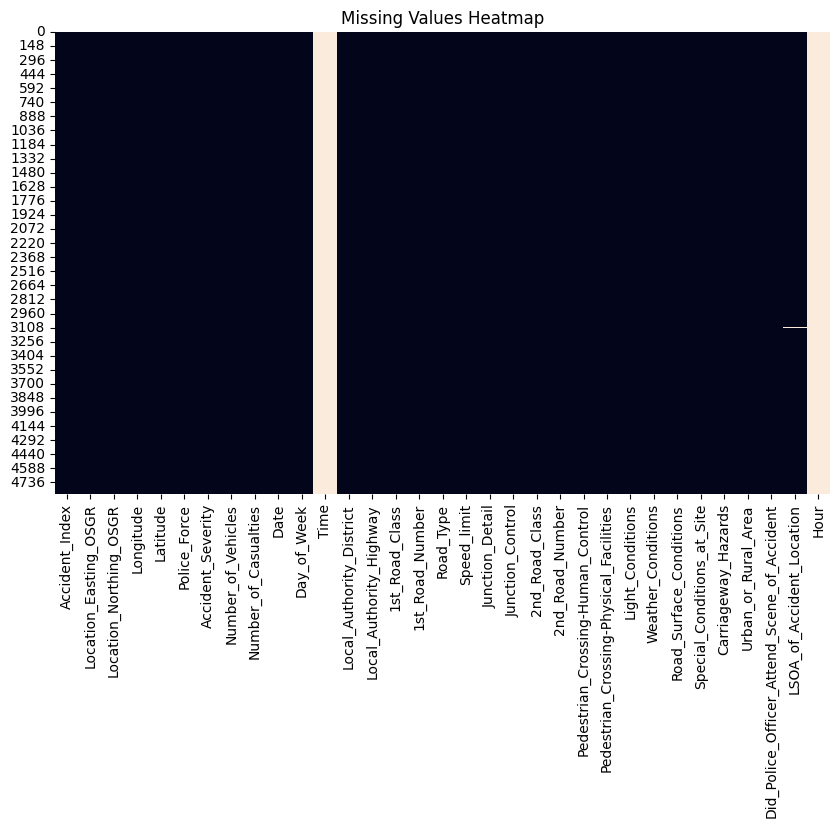


Number of rows with at least one missing value: 4857


,Accident_Index,Location_Easting_OSGR,Location_Northing_OSGR,Longitude,Latitude,Police_Force,Accident_Severity,Number_of_Vehicles,Number_of_Casualties,Date,...,Pedestrian_Crossing-Physical_Facilities,Light_Conditions,Weather_Conditions,Road_Surface_Conditions,Special_Conditions_at_Site,Carriageway_Hazards,Urban_or_Rural_Area,Did_Police_Officer_Attend_Scene_of_Accident,LSOA_of_Accident_Location,Hour
0,200501CP00187,532960,181880,-0.085002,51.520143,1,2,2,1,2005-08-25,...,0,4,1,1,0,0,1,1,E01000004,NaN
1,200501EK40106,531540,186860,-0.103597,51.565229,1,3,2,1,2005-02-19,...,0,1,1,1,0,0,1,2,E01002002,NaN
2,200501EO00029,532880,182520,-0.085913,51.525914,1,3,2,2,2005-01-10,...,0,1,2,2,0,0,1,1,E01002704,NaN
3,200501EO00043,533280,184790,-0.079292,51.546219,1,3,2,1,2005-01-12,...,0,1,1,1,0,0,1,1,E01001756,NaN
4,200501EO00144,533240,182630,-0.080685,51.526817,1,3,2,1,2005-01-21,...,5,4,2,2,0,0,1,1,E01001771,NaN


In [7]:
# Step 3.1: Missing values

print("Missing values per variable (count):")
missing_count = acc.isna().sum().sort_values(ascending=False)
display(missing_count)

print("\nMissing values per variable (percentage):")
missing_pct = (acc.isna().sum() / len(acc)).sort_values(ascending=False)
display(missing_pct)

# Heatmap of missing values
plt.figure(figsize=(10, 6))
sns.heatmap(acc.isna(), cbar=False)
plt.title('Missing Values Heatmap')
plt.show()

# Rows containing at least one missing value
rows_with_missing = acc[acc.isna().any(axis=1)]
print("\nNumber of rows with at least one missing value:", len(rows_with_missing))
display(rows_with_missing.head())


In [8]:
# Step 3.2: Outliers using z-score (numeric variables only)

acc_numeric = numeric_acc.copy()
z_scores = acc_numeric.apply(zscore)

# Absolute z-score
z_abs = np.abs(z_scores)

# Flag outliers as any value with |z| > 3
outlier_mask = (z_abs > 3)

print("Number of potential outliers per numeric variable (|z| > 3):")
outlier_counts = outlier_mask.sum().sort_values(ascending=False)
display(outlier_counts)

# Optional: view only the rows that contain at least one outlier
rows_with_outliers = acc_numeric[outlier_mask.any(axis=1)]
print("\nNumber of rows containing at least one potential outlier:", len(rows_with_outliers))
display(rows_with_outliers.head())


Number of potential outliers per numeric variable (|z| > 3):


,0
Road_Type,189
Number_of_Casualties,123
1st_Road_Number,110
Speed_limit,96
Number_of_Vehicles,52
2nd_Road_Number,51
Accident_Severity,28
Longitude,11
Location_Easting_OSGR,11
Location_Northing_OSGR,0



Number of rows containing at least one potential outlier: 601


,Location_Easting_OSGR,Location_Northing_OSGR,Longitude,Latitude,Accident_Severity,Number_of_Vehicles,Number_of_Casualties,1st_Road_Number,Road_Type,Speed_limit,Junction_Detail,Junction_Control,2nd_Road_Number,Hour
2,532880,182520,-0.085913,51.525914,3,2,2,5201,6,30,0,-1,0,NaN
4,533240,182630,-0.080685,51.526817,3,2,1,5201,6,30,3,2,0,NaN
6,532900,185400,-0.084539,51.551790,3,1,1,105,1,30,1,4,0,NaN
12,532910,182550,-0.085470,51.526176,3,1,1,5201,6,30,8,4,5201,NaN
14,532490,185840,-0.090283,51.555841,3,4,1,105,3,30,9,4,105,NaN


Accident_Severity distribution (count):


,count
Accident_Severity,
1,28
2,658
3,4171



Accident_Severity distribution (percentage):


,proportion
Accident_Severity,
1,0.005765
2,0.135475
3,0.858761


<Figure size 600x400 with 0 Axes>

<Axes: xlabel='Accident_Severity'>

Text(0.5, 0, 'Accident_Severity')

Text(0, 0.5, 'Count')

Text(0.5, 1.0, 'Distribution of Accident Severity')

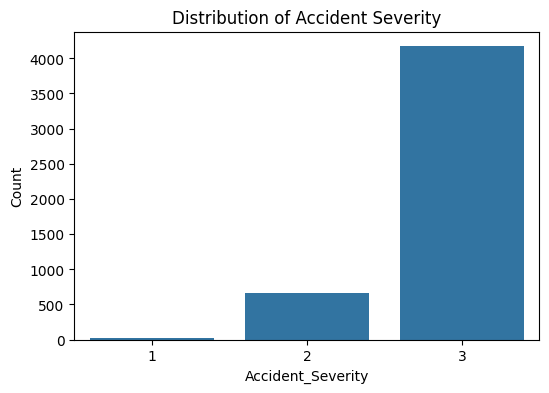

In [9]:
# Step 3.3: Class imbalance in Accident_Severity

if 'Accident_Severity' in acc.columns:
    severity_counts = acc['Accident_Severity'].value_counts().sort_index()
    severity_pct = acc['Accident_Severity'].value_counts(normalize=True).sort_index()

    print("Accident_Severity distribution (count):")
    display(severity_counts)

    print("\nAccident_Severity distribution (percentage):")
    display(severity_pct)

    plt.figure(figsize=(6,4))
    sns.barplot(x=severity_counts.index.astype(str), y=severity_counts.values)
    plt.xlabel('Accident_Severity')
    plt.ylabel('Count')
    plt.title('Distribution of Accident Severity')
    plt.show()


In [10]:
# Quick check that key fields exist for our business problems
required_cols = [
    'Accident_Severity',
    'Speed_limit',
    'Road_Type',
    '1st_Road_Class',
    'Junction_Detail',
    'Junction_Control',
    'Light_Conditions',
    'Weather_Conditions',
    'Road_Surface_Conditions',
    'Date',
    'Time',
    'Longitude',
    'Latitude'
]

missing_required = [c for c in required_cols if c not in acc.columns]
print("Required columns missing (should be empty list ideally):", missing_required)

print("\nShape of dataset (rows, columns):", acc.shape)
print(acc)


Required columns missing (should be empty list ideally): []

Shape of dataset (rows, columns): (4857, 33)
     Accident_Index  Location_Easting_OSGR  Location_Northing_OSGR  Longitude  \
0     200501CP00187                 532960                  181880  -0.085002   
1     200501EK40106                 531540                  186860  -0.103597   
2     200501EO00029                 532880                  182520  -0.085913   
3     200501EO00043                 533280                  184790  -0.079292   
4     200501EO00144                 533240                  182630  -0.080685   
...             ...                    ...                     ...        ...   
4852  201001YR90237                 532740                  187960  -0.085879   
4853  201001YR90297                 532740                  187960  -0.085879   
4854  201001YR90423                 532680                  185510  -0.087669   
4855  201001YR90474                 532050                  187470  -0.096014   
485

In [11]:
# Drop rows where Date could not be parsed (if any)
acc_clean = acc.dropna(subset=['Date'])

# (Optional) keep only rows with non-missing Accident_Severity
acc_clean = acc_clean.dropna(subset=['Accident_Severity'])

print("Shape after minimal cleaning:", acc_clean.shape)

acc_clean.to_csv('hackney_accidents_clean.csv', index=False)


Shape after minimal cleaning: (4857, 33)


In [12]:
# ============================================================
# STEP 4 – MODELLING (DESCRIPTIVE + PREDICTIVE)
# ============================================================

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree

# Optional: install mlxtend if not available (for association rules)
!pip install -q mlxtend

from mlxtend.frequent_patterns import apriori, association_rules

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [13]:
# ------------------------------------------------------------
# 4.1 Prepare feature sets for modelling (using acc_clean)
# ------------------------------------------------------------

# We'll work on a copy to keep acc_clean intact
data_model = acc_clean.copy()

# Some models will work better if Accident_Severity is grouped
# Typical coding in UK stats19: 1=Fatal, 2=Serious, 3=Slight
# We merge 1 and 2 into "Serious" to reduce imbalance.
severity_group_map = {
    1: "Serious",
    2: "Serious",
    3: "Slight"
}

if np.issubdtype(data_model['Accident_Severity'].dtype, np.number):
    data_model['Severity_Grouped'] = data_model['Accident_Severity'].map(severity_group_map)
else:
    # If already strings, normalise the labels a bit
    data_model['Severity_Grouped'] = (
        data_model['Accident_Severity']
        .astype(str)
        .str.strip()
        .replace({
            '1': 'Serious', '2': 'Serious', '3': 'Slight',
            'fatal': 'Serious', 'Fatal': 'Serious',
            'serious': 'Serious', 'Serious': 'Serious',
            'slight': 'Slight', 'Slight': 'Slight'
        })
    )

print("Severity_Grouped distribution:")
display(data_model['Severity_Grouped'].value_counts(dropna=False))
print("\n")

Severity_Grouped distribution:


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

,count
Severity_Grouped,
Slight,4171
Serious,686


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [16]:
# ============================================================
# 4.2 DESCRIPTIVE MODEL 1 – K-MEANS CLUSTERING (UPDATED & FIXED)
# ============================================================

cluster_numeric_features = [
    'Number_of_Vehicles',
    'Number_of_Casualties',
    'Speed_limit',
    'Hour',
    'Longitude',
    'Latitude'
]

cluster_categorical_features = [
    'Road_Type',
    'Junction_Detail',
    'Junction_Control',
    'Light_Conditions',
    'Weather_Conditions',
    'Road_Surface_Conditions',
    'Urban_or_Rural_Area'
]

# Keep only features that actually exist in your dataset
cluster_numeric_features = [c for c in cluster_numeric_features if c in data_model.columns]
cluster_categorical_features = [c for c in cluster_categorical_features if c in data_model.columns]

print("Numeric features used for clustering (initial):", cluster_numeric_features)
print("Categorical features used for clustering (initial):", cluster_categorical_features)

# Build dataframe (without dropping rows yet)
cluster_df = data_model[cluster_numeric_features + cluster_categorical_features].copy()

print("\nMissing values per clustering column BEFORE imputation:")
display(cluster_df.isna().sum())

# ---- Numeric imputation with special handling for fully-missing columns ----
for col in cluster_numeric_features.copy():   # use .copy() because we might modify the list
    cluster_df[col] = pd.to_numeric(cluster_df[col], errors='coerce')

    non_missing_count = cluster_df[col].notna().sum()
    if non_missing_count == 0:
        # Entire column is NaN → drop it
        print(f"Numeric column '{col}' is entirely missing – dropping from clustering.")
        cluster_df.drop(columns=[col], inplace=True)
        cluster_numeric_features.remove(col)
    else:
        median_val = cluster_df[col].median()
        cluster_df[col] = cluster_df[col].fillna(median_val)

# ---- Categorical imputation with special handling for fully-missing columns ----
for col in cluster_categorical_features.copy():
    cluster_df[col] = cluster_df[col].astype('category')
    if cluster_df[col].isna().all():
        print(f"Categorical column '{col}' is entirely missing – dropping from clustering.")
        cluster_df.drop(columns=[col], inplace=True)
        cluster_categorical_features.remove(col)
    else:
        mode_val = cluster_df[col].mode().iloc[0]
        cluster_df[col] = cluster_df[col].fillna(mode_val)

print("\nMissing values per clustering column AFTER imputation:")
display(cluster_df.isna().sum())

print("\nFinal numeric features used for clustering:", cluster_numeric_features)
print("Final categorical features used for clustering:", cluster_categorical_features)
print("\nShape of data used for clustering (after imputation):", cluster_df.shape)

# Safety check on row count
if cluster_df.shape[0] < 2:
    print("❗ Not enough rows for clustering even after imputation. "
          "You may need to reduce the feature list or check your dataset.")
else:
    # One-hot encode categorical features
    cluster_cat_ohe = pd.get_dummies(
        cluster_df[cluster_categorical_features].astype('category'),
        drop_first=True
    )

    # Standardise numeric features
    scaler = StandardScaler()
    cluster_num_scaled = pd.DataFrame(
        scaler.fit_transform(cluster_df[cluster_numeric_features].astype(float)),
        columns=cluster_numeric_features,
        index=cluster_df.index
    )

    # Final feature matrix for clustering
    X_cluster = pd.concat([cluster_num_scaled, cluster_cat_ohe], axis=1)

    print("Shape of X_cluster (features for K-means):", X_cluster.shape)

    # 🔍 Extra safety: check for any remaining NaNs
    na_per_col = X_cluster.isna().sum()
    print("\nRemaining missing values per column in X_cluster (non-zero only):")
    display(na_per_col[na_per_col > 0])

    # If any remain, drop those rows
    if na_per_col.sum() > 0:
        valid_mask = ~X_cluster.isna().any(axis=1)
        print("Dropping", (~valid_mask).sum(), "rows with remaining NaNs before K-means.")
        X_cluster = X_cluster[valid_mask]
        cluster_df_for_kmeans = cluster_df.loc[X_cluster.index]
    else:
        cluster_df_for_kmeans = cluster_df.copy()

    print("\nShape of X_cluster after dropping NaN rows (if any):", X_cluster.shape)

    # --------------------------------------------------------
    # Run K-means on X_cluster and attach labels back
    # --------------------------------------------------------
    kmeans = KMeans(
        n_clusters=3,     # you can justify k=3 in the report
        random_state=42,
        n_init=10
    )

    cluster_labels = kmeans.fit_predict(X_cluster)

    # Optional: silhouette score to comment on quality of clustering
    sil_score = silhouette_score(X_cluster, cluster_labels)
    print(f"\nSilhouette score for K-means (k=3): {sil_score:.3f}")

    # Attach clusters back to the original modelling data
    acc_clustered = data_model.loc[cluster_df_for_kmeans.index].copy()
    acc_clustered['Cluster'] = cluster_labels

    print("\nCluster sizes:")
    print(acc_clustered['Cluster'].value_counts().sort_index())


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

Numeric features used for clustering (initial): ['Number_of_Vehicles', 'Number_of_Casualties', 'Speed_limit', 'Hour', 'Longitude', 'Latitude']
Categorical features used for clustering (initial): ['Road_Type', 'Junction_Detail', 'Junction_Control', 'Light_Conditions', 'Weather_Conditions', 'Road_Surface_Conditions', 'Urban_or_Rural_Area']

Missing values per clustering column BEFORE imputation:


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

,0
Number_of_Vehicles,0
Number_of_Casualties,0
Speed_limit,0
Hour,4857
Longitude,0
Latitude,0
Road_Type,0
Junction_Detail,0
Junction_Control,0
Light_Conditions,0


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

...

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag


Shape of X_cluster after dropping NaN rows (if any): (4857, 37)


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag


Silhouette score for K-means (k=3): 0.162

Cluster sizes:
Cluster
0      93
1    3160
2    1604
Name: count, dtype: int64


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [17]:
# ============================================================
# 4.3 DESCRIPTIVE MODEL 2 – ASSOCIATION RULE ANALYSIS
# ============================================================

# We'll focus on categorical conditions and severity for co-occurrence patterns
assoc_cols = [
    'Severity_Grouped',
    'Road_Type',
    'Junction_Detail',
    'Junction_Control',
    'Light_Conditions',
    'Weather_Conditions',
    'Road_Surface_Conditions',
    'Urban_or_Rural_Area'
]

assoc_cols = [c for c in assoc_cols if c in data_model.columns]

assoc_df = data_model[assoc_cols].dropna().copy()

print("\nShape of data used for association rules:", assoc_df.shape)

# Convert everything to string and one-hot encode
for col in assoc_cols:
    assoc_df[col] = assoc_df[col].astype(str).str.strip()

assoc_ohe = pd.get_dummies(assoc_df, dtype=int)

print("Shape of one-hot encoded data for association rules:", assoc_ohe.shape)

# Generate frequent itemsets
freq_itemsets = apriori(assoc_ohe, min_support=0.02, use_colnames=True)
print("\nNumber of frequent itemsets (support >= 0.02):", len(freq_itemsets))
display(freq_itemsets.head())

# Generate association rules
rules = association_rules(freq_itemsets, metric="confidence", min_threshold=0.6)
print("\nNumber of raw association rules (confidence >= 0.6):", len(rules))

# Keep only rules where the consequent contains Severity_Grouped
rules['consequent_str'] = rules['consequents'].astype(str)
rules_severity = rules[rules['consequent_str'].str.contains('Severity_Grouped')].copy()

# Sort by lift and confidence
rules_severity = rules_severity.sort_values(['lift', 'confidence'], ascending=False)

print("\nAssociation rules with Severity_Grouped in the consequent (top 20):")
display(rules_severity.head(20))


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag


Shape of data used for association rules: (4857, 8)
Shape of one-hot encoded data for association rules: (4857, 41)


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag


Number of frequent itemsets (support >= 0.02): 1787


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


...

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag


Number of raw association rules (confidence >= 0.6): 16349

Association rules with Severity_Grouped in the consequent (top 20):


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski,consequent_str
9518,"(Junction_Detail_3, Weather_Conditions_2)","(Road_Surface_Conditions_2, Road_Type_6, Sever...",0.040354,0.063208,0.028413,0.704082,11.139168,1.0,0.025862,3.165712,0.948503,0.378082,0.684115,0.576797,"frozenset({'Road_Surface_Conditions_2', 'Road_..."
14336,"(Weather_Conditions_2, Junction_Detail_3, Urba...","(Road_Surface_Conditions_2, Road_Type_6, Sever...",0.040354,0.063208,0.028413,0.704082,11.139168,1.0,0.025862,3.165712,0.948503,0.378082,0.684115,0.576797,"frozenset({'Road_Surface_Conditions_2', 'Road_..."
14340,"(Junction_Detail_3, Weather_Conditions_2)","(Road_Surface_Conditions_2, Severity_Grouped_S...",0.040354,0.063208,0.028413,0.704082,11.139168,1.0,0.025862,3.165712,0.948503,0.378082,0.684115,0.576797,"frozenset({'Road_Surface_Conditions_2', 'Sever..."
9517,"(Road_Type_6, Junction_Control_4, Weather_Cond...","(Road_Surface_Conditions_2, Severity_Grouped_S...",0.042207,0.061972,0.028413,0.673171,10.862426,1.0,0.025797,2.870084,0.947950,0.375000,0.651578,0.565821,"frozenset({'Road_Surface_Conditions_2', 'Sever..."
14332,"(Road_Type_6, Weather_Conditions_2, Junction_C...","(Road_Surface_Conditions_2, Severity_Grouped_S...",0.042207,0.061972,0.028413,0.673171,10.862426,1.0,0.025797,2.870084,0.947950,0.375000,0.651578,0.565821,"frozenset({'Road_Surface_Conditions_2', 'Sever..."
14339,"(Road_Type_6, Junction_Control_4, Weather_Cond...","(Road_Surface_Conditions_2, Severity_Grouped_S...",0.042207,0.061972,0.028413,0.673171,10.862426,1.0,0.025797,2.870084,0.947950,0.375000,0.651578,0.565821,"frozenset({'Road_Surface_Conditions_2', 'Sever..."
9515,"(Road_Type_6, Junction_Detail_3, Weather_Condi...","(Road_Surface_Conditions_2, Severity_Grouped_S...",0.037883,0.072679,0.028413,0.750000,10.319405,1.0,0.025659,3.709286,0.938655,0.345865,0.730406,0.570467,"frozenset({'Road_Surface_Conditions_2', 'Sever..."
14329,"(Road_Type_6, Weather_Conditions_2, Junction_D...","(Road_Surface_Conditions_2, Severity_Grouped_S...",0.037883,0.072679,0.028413,0.750000,10.319405,1.0,0.025659,3.709286,0.938655,0.345865,0.730406,0.570467,"frozenset({'Road_Surface_Conditions_2', 'Sever..."
14337,"(Road_Type_6, Junction_Detail_3, Weather_Condi...","(Road_Surface_Conditions_2, Severity_Grouped_S...",0.037883,0.072679,0.028413,0.750000,10.319405,1.0,0.025659,3.709286,0.938655,0.345865,0.730406,0.570467,"frozenset({'Road_Surface_Conditions_2', 'Sever..."
5717,"(Junction_Detail_3, Weather_Conditions_2)","(Road_Surface_Conditions_2, Severity_Grouped_S...",0.040354,0.072679,0.030060,0.744898,10.249205,1.0,0.027127,3.635100,0.940380,0.362283,0.724904,0.579248,"frozenset({'Road_Surface_Conditions_2', 'Sever..."


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [18]:
# ============================================================
# 4.4 PREDICTIVE MODEL – DECISION TREE FOR SEVERITY (UPDATED)
# ============================================================

# We build a supervised model predicting Severity_Grouped from context features.

# Select predictor features
dt_numeric_features = [
    'Number_of_Vehicles',
    'Number_of_Casualties',
    'Speed_limit',
    'Hour'
]

dt_categorical_features = [
    'Road_Type',
    'Junction_Detail',
    'Junction_Control',
    'Light_Conditions',
    'Weather_Conditions',
    'Road_Surface_Conditions',
    'Urban_or_Rural_Area',
    'Police_Force'
]

dt_numeric_features = [c for c in dt_numeric_features if c in data_model.columns]
dt_categorical_features = [c for c in dt_categorical_features if c in data_model.columns]

print("\nNumeric features used for decision tree:", dt_numeric_features)
print("Categorical features used for decision tree:", dt_categorical_features)

# 1) Build dataframe (DO NOT drop everything yet)
dt_df = data_model[dt_numeric_features + dt_categorical_features + ['Severity_Grouped']].copy()

# 2) Drop rows only where the TARGET is missing
dt_df = dt_df.dropna(subset=['Severity_Grouped'])

print("\nRows after dropping missing target (Severity_Grouped):", dt_df.shape[0])

# 3) Impute numeric features with median
for col in dt_numeric_features:
    dt_df[col] = dt_df[col].astype(float)
    median_val = dt_df[col].median()
    dt_df[col] = dt_df[col].fillna(median_val)

# 4) Impute categorical features with mode (or drop if completely missing)
for col in dt_categorical_features:
    dt_df[col] = dt_df[col].astype('category')
    if dt_df[col].isna().all():
        print(f"Column '{col}' is entirely missing – it will be dropped from the model.")
        dt_df.drop(columns=[col], inplace=True)
    else:
        mode_val = dt_df[col].mode().iloc[0]
        dt_df[col] = dt_df[col].fillna(mode_val)

print("\nMissing values per column AFTER imputation:")
display(dt_df.isna().sum())

print("\nShape of data used for decision tree (after imputation):", dt_df.shape)

# Safety check
if dt_df.shape[0] < 2:
    print("❗ Not enough rows to train a decision tree even after imputation.")
else:
    # 5) Build X and y
    X_num_dt = dt_df[dt_numeric_features].astype(float)
    used_cat_features = [c for c in dt_categorical_features if c in dt_df.columns]
    X_cat_dt = pd.get_dummies(dt_df[used_cat_features].astype('category'), drop_first=True)

    X_dt = pd.concat([X_num_dt, X_cat_dt], axis=1)
    y_dt = dt_df['Severity_Grouped'].astype(str)  # cast to string labels

    # 6) Train-test split (stratified to keep class proportions)
    X_train_dt, X_test_dt, y_train_dt, y_test_dt = train_test_split(
        X_dt, y_dt, test_size=0.3, random_state=42, stratify=y_dt
    )

    print("\nTrain set size:", X_train_dt.shape[0])
    print("Test set size :", X_test_dt.shape[0])


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag


Numeric features used for decision tree: ['Number_of_Vehicles', 'Number_of_Casualties', 'Speed_limit', 'Hour']
Categorical features used for decision tree: ['Road_Type', 'Junction_Detail', 'Junction_Control', 'Light_Conditions', 'Weather_Conditions', 'Road_Surface_Conditions', 'Urban_or_Rural_Area', 'Police_Force']

Rows after dropping missing target (Severity_Grouped): 4857

Missing values per column AFTER imputation:


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,0
Number_of_Vehicles,0
Number_of_Casualties,0
Speed_limit,0
Hour,4857
Road_Type,0
Junction_Detail,0
Junction_Control,0
Light_Conditions,0
Weather_Conditions,0
Road_Surface_Conditions,0


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag


Shape of data used for decision tree (after imputation): (4857, 13)

Train set size: 3399
Test set size : 1458


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [19]:
# ------------------------------------------------------------
# 4.4.1 Fit entropy-based decision tree
# ------------------------------------------------------------

dt_clf = DecisionTreeClassifier(
    criterion='entropy',
    max_depth=6,          # a moderate depth for interpretability
    min_samples_leaf=50,  # avoids tiny leaves / overfitting
    random_state=42
)

dt_clf.fit(X_train_dt, y_train_dt)

print("\nDecision tree trained.")

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

DecisionTreeClassifier(criterion='entropy', max_depth=6, min_samples_leaf=50,
                       random_state=42)

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)



Decision tree trained.


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

DecisionTreeClassifier(max_depth=5, min_samples_leaf=50, random_state=42)

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag


Classification report (Decision Tree):
              precision    recall  f1-score   support

     Serious       0.00      0.00      0.00       206
      Slight       0.86      1.00      0.92      1252

    accuracy                           0.86      1458
   macro avg       0.43      0.50      0.46      1458
weighted avg       0.74      0.86      0.79      1458


Confusion matrix:
[[   0  206]
 [   0 1252]]


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


...

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

[Text(0.483695652173913, 0.9166666666666666, 'Number_of_Vehicles <= 1.5\ngini = 0.243\nsamples = 3399\nvalue = [480.0, 2919.0]\nclass = Slight'),
 Text(0.21739130434782608, 0.75, 'Number_of_Casualties <= 1.5\ngini = 0.311\nsamples = 1077\nvalue = [207, 870]\nclass = Slight'),
 Text(0.35054347826086957, 0.8333333333333333, 'True  '),
 Text(0.17391304347826086, 0.5833333333333334, 'Light_Conditions_4 <= 0.5\ngini = 0.295\nsamples = 990\nvalue = [178, 812]\nclass = Slight'),
 Text(0.08695652173913043, 0.4166666666666667, 'Road_Type_6 <= 0.5\ngini = 0.269\nsamples = 694\nvalue = [111, 583]\nclass = Slight'),
 Text(0.043478260869565216, 0.25, 'gini = 0.358\nsamples = 77\nvalue = [18, 59]\nclass = Slight'),
 Text(0.13043478260869565, 0.25, 'Junction_Control_4 <= 0.5\ngini = 0.256\nsamples = 617\nvalue = [93.0, 524.0]\nclass = Slight'),
 Text(0.08695652173913043, 0.08333333333333333, 'gini = 0.283\nsamples = 276\nvalue = [47, 229]\nclass = Slight'),
 Text(0.17391304347826086, 0.08333333333333

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

Text(0.5, 1.0, 'Decision Tree for Accident Severity (Grouped)')

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

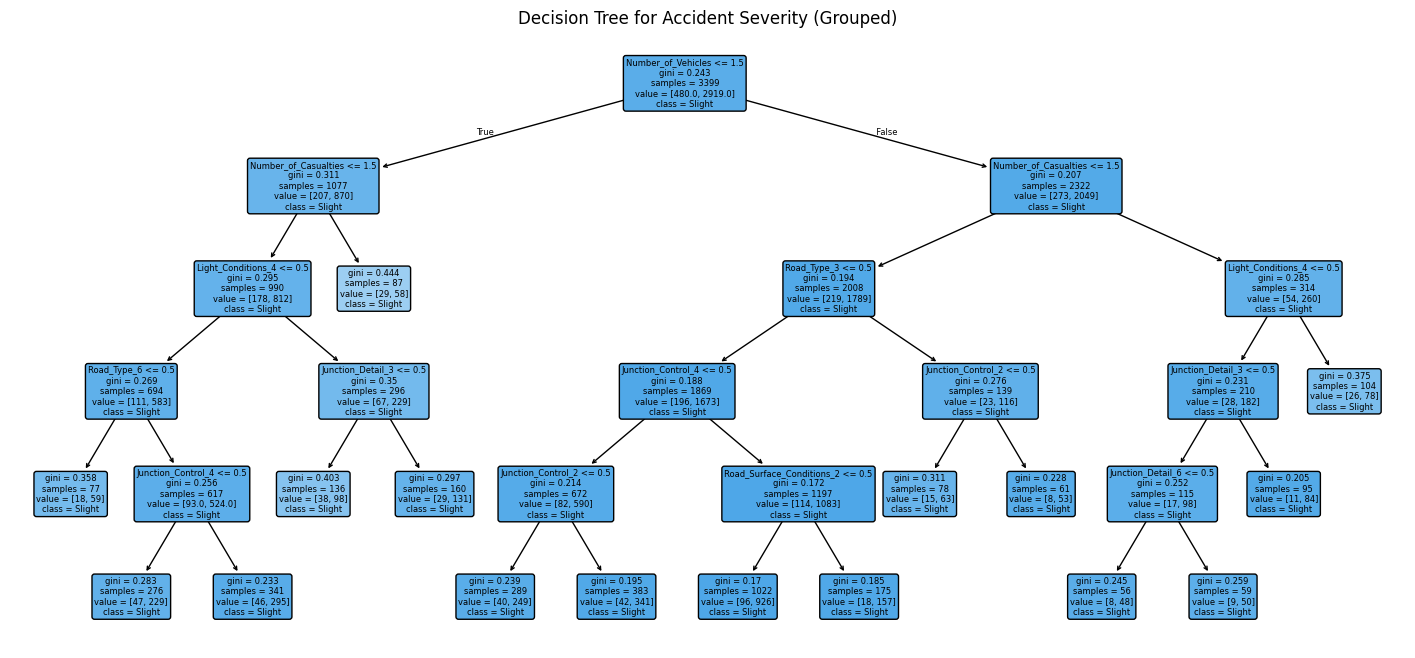

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [20]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import classification_report, confusion_matrix

dt_clf = DecisionTreeClassifier(
    max_depth=5,
    min_samples_leaf=50,
    random_state=42
)
dt_clf.fit(X_train_dt, y_train_dt)

y_pred_dt = dt_clf.predict(X_test_dt)

print("\nClassification report (Decision Tree):")
print(classification_report(y_test_dt, y_pred_dt))

print("\nConfusion matrix:")
print(confusion_matrix(y_test_dt, y_pred_dt))

plt.figure(figsize=(18, 8))
plot_tree(
    dt_clf,
    feature_names=X_dt.columns,
    class_names=sorted(y_dt.unique().tolist()),
    filled=True,
    rounded=True,
    fontsize=6
)
plt.title("Decision Tree for Accident Severity (Grouped)")
plt.show()


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag


=== Cluster profile: numeric features (mean / median / min / max / count) ===


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Number_of_Vehicles                      Number_of_Casualties         \
                      mean median min max count                 mean median   
Cluster                                                                       
0                 1.924731    2.0   1   6    93             1.161290    1.0   
1                 1.732911    2.0   1   8  3160             1.149051    1.0   
2                 1.769950    2.0   1   7  1604             1.183915    1.0   

                       ... Longitude                                      \
        min max count  ...      mean    median       min       max count   
Cluster                ...                                                 
0         1   3    93  ... -0.052929 -0.041517 -0.103309 -0.016897    93   
1         1  10  3160  ... -0.064409 -0.068411 -0.093816 -0.017800  3160   
2         1   8  1604  ... -0.078163 -0.074461 -0.104193 -0.047491  1604   

          Latitude                                         
              mean     median        min        max count  
Cluster                                                    
0        51.550114  51.549105  51.522634  51.574332    93  
1        51.541595  51.544098  51.519793  51.562121  3160  
2        51.565368  51.565684  51.548704  51.576455  1604  

[3 rows x 25 columns]

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

...

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

Text(0, 0.5, 'Average number of casualties')

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Text(0.5, 1.0, 'Mean casualties per cluster')

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


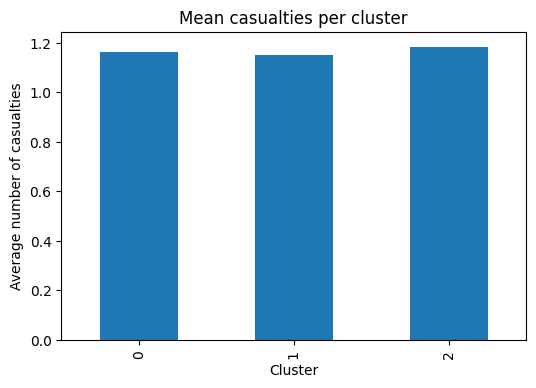

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [21]:
# ============================================================
# STEP 5 – EVALUATION OF MODELS
# ============================================================

# ------------------------------------------------------------
# 5.1 Evaluate K-means clusters (descriptive)
# ------------------------------------------------------------

print("\n=== Cluster profile: numeric features (mean / median / min / max / count) ===")
cluster_profile_numeric = acc_clustered.groupby('Cluster')[cluster_numeric_features].agg(['mean', 'median', 'min', 'max', 'count'])
display(cluster_profile_numeric)

if 'Accident_Severity' in acc_clustered.columns:
    print("\n=== Severity distribution by cluster (row-normalised) ===")
    severity_by_cluster = pd.crosstab(
        acc_clustered['Cluster'],
        acc_clustered['Accident_Severity'],
        normalize='index'
    )
    display(severity_by_cluster)

# Simple visualisation – average number of casualties per cluster
plt.figure(figsize=(6,4))
cluster_profile_numeric['Number_of_Casualties']['mean'].plot(kind='bar')
plt.ylabel('Average number of casualties')
plt.title('Mean casualties per cluster')
plt.show()

In [22]:
# ------------------------------------------------------------
# 5.2 Evaluate association rules (support, confidence, lift)
# ------------------------------------------------------------

print("\n=== Summary of severity-related rules ===")
if not rules_severity.empty:
    summary_cols = ['antecedents', 'consequents', 'support', 'confidence', 'lift']
    display(rules_severity[summary_cols].head(20))
else:
    print("No severity-related rules found with the chosen support/confidence thresholds.")
    print("You can try lowering min_support or min_threshold in the apriori / association_rules steps.")


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag


=== Summary of severity-related rules ===


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,antecedents,consequents,support,confidence,lift
9518,"(Junction_Detail_3, Weather_Conditions_2)","(Road_Surface_Conditions_2, Road_Type_6, Sever...",0.028413,0.704082,11.139168
14336,"(Weather_Conditions_2, Junction_Detail_3, Urba...","(Road_Surface_Conditions_2, Road_Type_6, Sever...",0.028413,0.704082,11.139168
14340,"(Junction_Detail_3, Weather_Conditions_2)","(Road_Surface_Conditions_2, Severity_Grouped_S...",0.028413,0.704082,11.139168
9517,"(Road_Type_6, Junction_Control_4, Weather_Cond...","(Road_Surface_Conditions_2, Severity_Grouped_S...",0.028413,0.673171,10.862426
14332,"(Road_Type_6, Weather_Conditions_2, Junction_C...","(Road_Surface_Conditions_2, Severity_Grouped_S...",0.028413,0.673171,10.862426
14339,"(Road_Type_6, Junction_Control_4, Weather_Cond...","(Road_Surface_Conditions_2, Severity_Grouped_S...",0.028413,0.673171,10.862426
9515,"(Road_Type_6, Junction_Detail_3, Weather_Condi...","(Road_Surface_Conditions_2, Severity_Grouped_S...",0.028413,0.750000,10.319405
14329,"(Road_Type_6, Weather_Conditions_2, Junction_D...","(Road_Surface_Conditions_2, Severity_Grouped_S...",0.028413,0.750000,10.319405
14337,"(Road_Type_6, Junction_Detail_3, Weather_Condi...","(Road_Surface_Conditions_2, Severity_Grouped_S...",0.028413,0.750000,10.319405
5717,"(Junction_Detail_3, Weather_Conditions_2)","(Road_Surface_Conditions_2, Severity_Grouped_S...",0.030060,0.744898,10.249205


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag


=== Decision tree performance ===
Training accuracy: 0.859
Test accuracy:     0.859

Classification report (test set):
              precision    recall  f1-score   support

     Serious       0.00      0.00      0.00       206
      Slight       0.86      1.00      0.92      1252

    accuracy                           0.86      1458
   macro avg       0.43      0.50      0.46      1458
weighted avg       0.74      0.86      0.79      1458



/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

Text(0.5, 1.0, 'Confusion Matrix – Decision Tree (Severity_Grouped)')

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

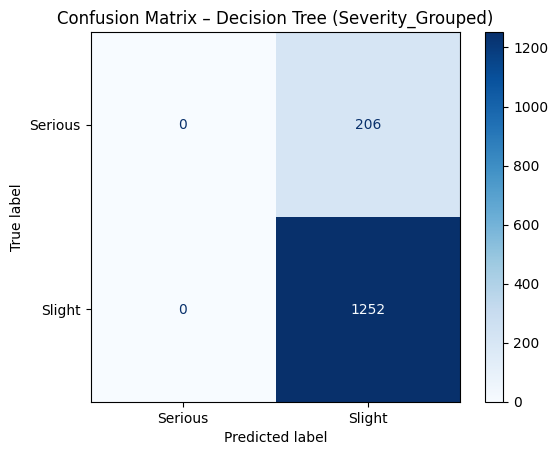

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag


Approximate SSE on test set (Severity_Grouped coded as Slight=0, Serious=1): 206


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [23]:
# ------------------------------------------------------------
# 5.3 Evaluate decision tree (accuracy, confusion matrix, SSE)
# ------------------------------------------------------------

# Predictions
y_train_pred_dt = dt_clf.predict(X_train_dt)
y_test_pred_dt = dt_clf.predict(X_test_dt)

# Accuracy
train_acc = accuracy_score(y_train_dt, y_train_pred_dt)
test_acc = accuracy_score(y_test_dt, y_test_pred_dt)

print("\n=== Decision tree performance ===")
print(f"Training accuracy: {train_acc:.3f}")
print(f"Test accuracy:     {test_acc:.3f}")

# Classification report (test set)
print("\nClassification report (test set):")
print(classification_report(y_test_dt, y_test_pred_dt))

# Confusion matrix
cm = confusion_matrix(y_test_dt, y_test_pred_dt, labels=dt_clf.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=dt_clf.classes_)
disp.plot(cmap='Blues')
plt.title("Confusion Matrix – Decision Tree (Severity_Grouped)")
plt.show()

# Approximate SSE by mapping labels to numeric codes
severity_numeric_map = {'Slight': 0, 'Serious': 1}
y_test_num = y_test_dt.map(severity_numeric_map)
y_pred_num = pd.Series(y_test_pred_dt, index=y_test_dt.index).map(severity_numeric_map)

sse_test = np.sum((y_test_num - y_pred_num) ** 2)
print(f"\nApproximate SSE on test set (Severity_Grouped coded as Slight=0, Serious=1): {sse_test}")


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

<Figure size 2200x1000 with 0 Axes>

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

[Text(0.4880952380952381, 0.9, 'Number_of_Vehicles <= 1.5\ngini = 0.243\nsamples = 3399\nvalue = [480.0, 2919.0]\nclass = Slight'),
 Text(0.23809523809523808, 0.7, 'Number_of_Casualties <= 1.5\ngini = 0.311\nsamples = 1077\nvalue = [207, 870]\nclass = Slight'),
 Text(0.3630952380952381, 0.8, 'True  '),
 Text(0.19047619047619047, 0.5, 'Light_Conditions_4 <= 0.5\ngini = 0.295\nsamples = 990\nvalue = [178, 812]\nclass = Slight'),
 Text(0.09523809523809523, 0.3, 'Road_Type_6 <= 0.5\ngini = 0.269\nsamples = 694\nvalue = [111, 583]\nclass = Slight'),
 Text(0.047619047619047616, 0.1, '\n  (...)  \n'),
 Text(0.14285714285714285, 0.1, '\n  (...)  \n'),
 Text(0.2857142857142857, 0.3, 'Junction_Detail_3 <= 0.5\ngini = 0.35\nsamples = 296\nvalue = [67, 229]\nclass = Slight'),
 Text(0.23809523809523808, 0.1, '\n  (...)  \n'),
 Text(0.3333333333333333, 0.1, '\n  (...)  \n'),
 Text(0.2857142857142857, 0.5, 'gini = 0.444\nsamples = 87\nvalue = [29, 58]\nclass = Slight'),
 Text(0.7380952380952381, 0.7,

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

Text(0.5, 1.0, 'Decision Tree (top levels only)')

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

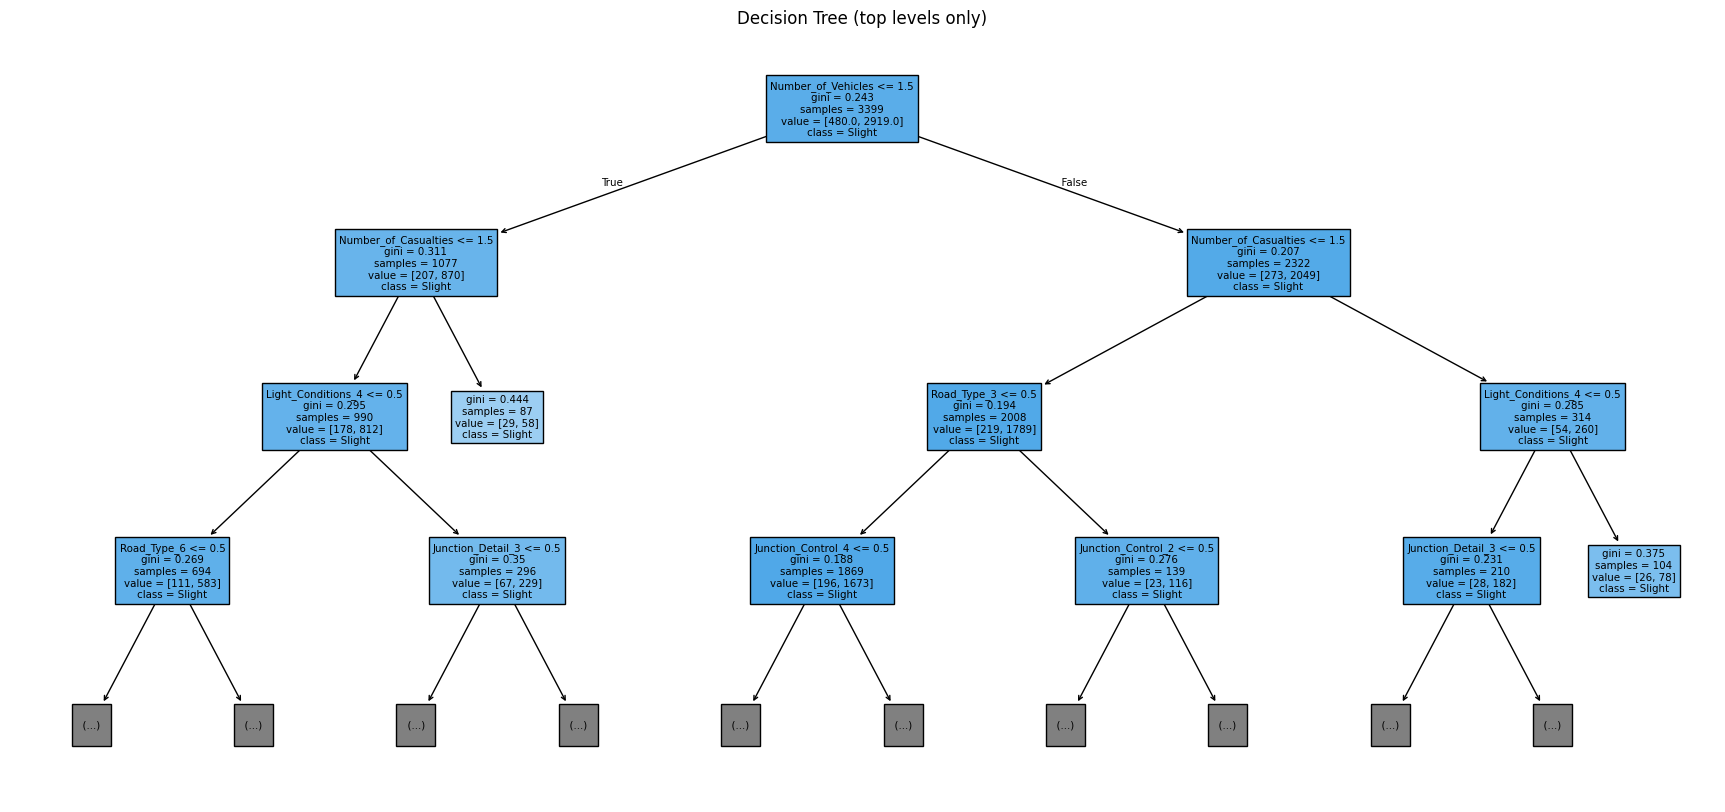

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag


Top 20 most important features in the decision tree:


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

,0
Number_of_Vehicles,0.359235
Number_of_Casualties,0.259480
Light_Conditions_4,0.163217
Junction_Detail_3,0.066780
Junction_Control_4,0.043821
Road_Type_3,0.041650
Road_Type_6,0.041380
Junction_Control_2,0.023158
Road_Surface_Conditions_2,0.001043
Junction_Detail_6,0.000236


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [24]:
# ------------------------------------------------------------
# 5.4 Visualise the decision tree (structure / rules)
# ------------------------------------------------------------

plt.figure(figsize=(22, 10))
plot_tree(
    dt_clf,
    feature_names=X_dt.columns,
    class_names=dt_clf.classes_,
    filled=True,
    max_depth=3  # only show top levels for readability
)
plt.title("Decision Tree (top levels only)")
plt.show()

# Optional: feature importances
importances = pd.Series(dt_clf.feature_importances_, index=X_dt.columns)
importances = importances.sort_values(ascending=False)

print("\nTop 20 most important features in the decision tree:")
display(importances.head(20))


In [25]:
# ============================================================
# STEP 6 – EXPORT KEY TABLES FOR THE WRITTEN REPORT
# ============================================================

# 6.1 Export cluster profile & severity distribution
cluster_profile_numeric.to_csv("hackney_cluster_profile_numeric.csv")
if 'Accident_Severity' in acc_clustered.columns:
    severity_by_cluster.to_csv("hackney_severity_by_cluster.csv")

# 6.2 Export severity-related association rules
if not rules_severity.empty:
    rules_severity.to_csv("hackney_association_rules_severity.csv", index=False)

# 6.3 Export decision tree metrics summary
metrics_summary = pd.DataFrame({
    'Metric': ['Training accuracy', 'Test accuracy', 'Test SSE (binary Serious/Slight)'],
    'Value': [train_acc, test_acc, sse_test]
})
metrics_summary.to_csv("hackney_decision_tree_metrics.csv", index=False)

print("\nFiles saved:")
print(" - hackney_cluster_profile_numeric.csv")
if 'Accident_Severity' in acc_clustered.columns:
    print(" - hackney_severity_by_cluster.csv")
if not rules_severity.empty:
    print(" - hackney_association_rules_severity.csv")
print(" - hackney_decision_tree_metrics.csv")
print("\nYou can download these from the Colab left panel and use them in your written Task 5 & 6 report.")

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag


Files saved:
 - hackney_cluster_profile_numeric.csv
 - hackney_severity_by_cluster.csv
 - hackney_association_rules_severity.csv
 - hackney_decision_tree_metrics.csv

You can download these from the Colab left panel and use them in your written Task 5 & 6 report.


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag